In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(1679.5), np.float64(1119.5), np.float64(-0.5))

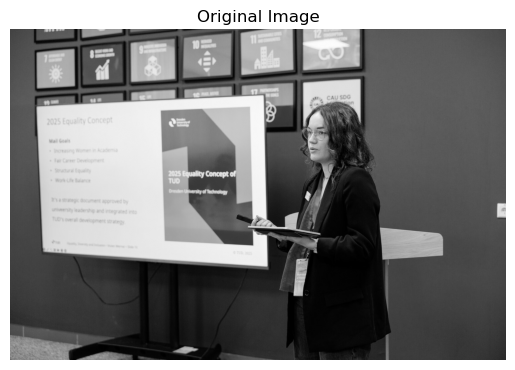

In [7]:
import urllib.request

url = 'https://static.tildacdn.com/tild6563-3138-4836-b462-393232336532/CR6_7301.jpg'
urllib.request.urlretrieve(url, 'image.png')

image = cv2.imread('image.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

(np.float64(-0.5), np.float64(1679.5), np.float64(1119.5), np.float64(-0.5))

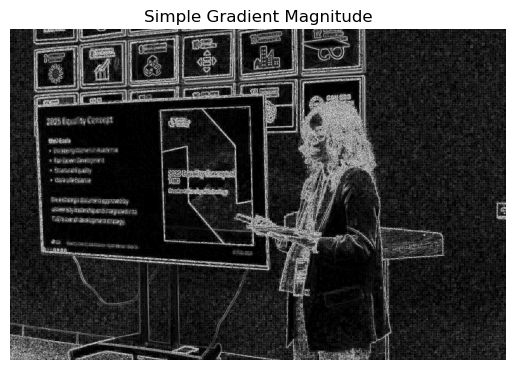

In [8]:
gx = np.zeros_like(image)
gy = np.zeros_like(image)

gx[:, :-1] = np.diff(image, axis=1)
gy[:-1, :] = np.diff(image, axis=0)

gradient_magnitude = np.sqrt(gx**2 + gy**2)

plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Simple Gradient Magnitude')
plt.axis('off')

(np.float64(-0.5), np.float64(1679.5), np.float64(1119.5), np.float64(-0.5))

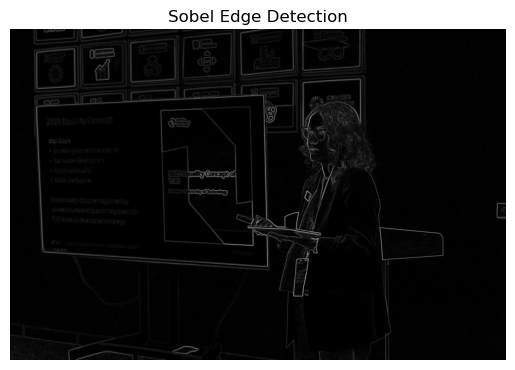

In [9]:
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')

(np.float64(-0.5), np.float64(1679.5), np.float64(1119.5), np.float64(-0.5))

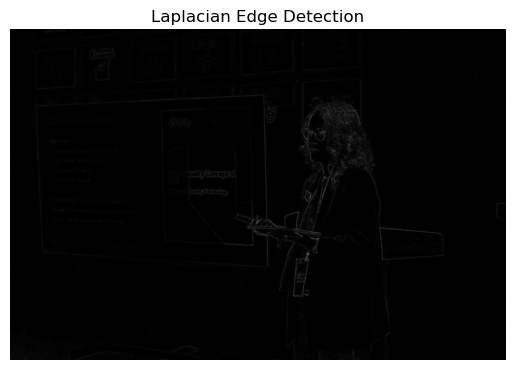

In [10]:
laplacian = cv2.Laplacian(image, cv2.CV_64F)

plt.imshow(np.abs(laplacian), cmap='gray')
plt.title('Laplacian Edge Detection')
plt.axis('off')

(np.float64(-0.5), np.float64(1679.5), np.float64(1119.5), np.float64(-0.5))

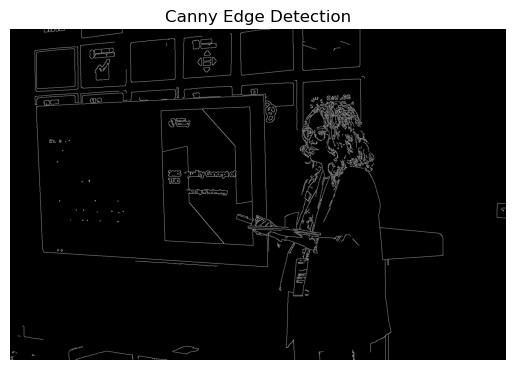

In [11]:
canny = cv2.Canny(image, 100, 200)

plt.imshow(canny, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

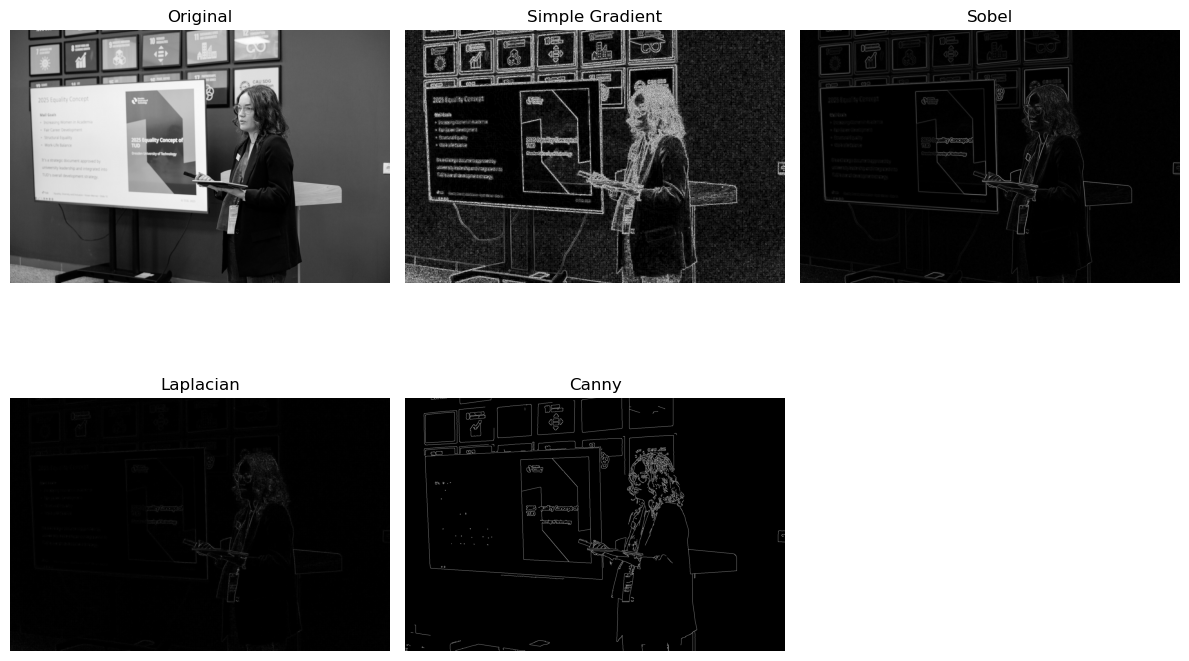

In [13]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Simple Gradient')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(np.abs(laplacian), cmap='gray')
plt.title('Laplacian')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(canny, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.tight_layout()
plt.show()

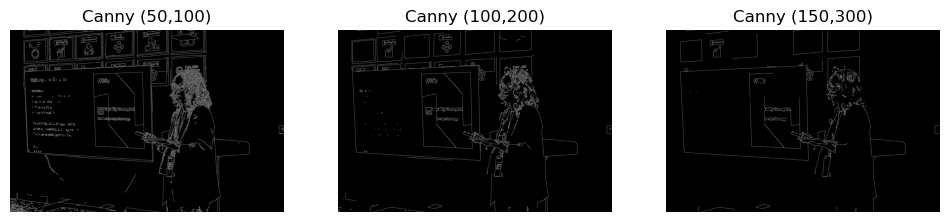

In [14]:
#TASK 1:
canny1 = cv2.Canny(image, 50, 100)
canny2 = cv2.Canny(image, 100, 200)
canny3 = cv2.Canny(image, 150, 300)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(canny1, cmap='gray')
plt.title('Canny (50,100)')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(canny2, cmap='gray')
plt.title('Canny (100,200)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(canny3, cmap='gray')
plt.title('Canny (150,300)')
plt.axis('off')

plt.show()

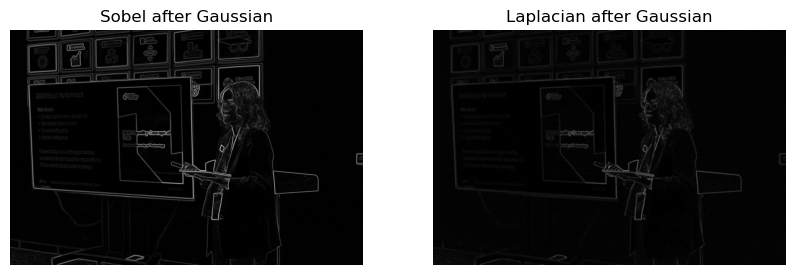

In [15]:
#TASK 2:
# Apply Gaussian blur
blur = cv2.GaussianBlur(image, (5,5), 0)

# Sobel after blur
sobel_x_blur = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_blur = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
sobel_blur = np.sqrt(sobel_x_blur**2 + sobel_y_blur**2)

# Laplacian after blur
laplacian_blur = cv2.Laplacian(blur, cv2.CV_64F)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(sobel_blur, cmap='gray')
plt.title('Sobel after Gaussian')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(np.abs(laplacian_blur), cmap='gray')
plt.title('Laplacian after Gaussian')
plt.axis('off')

plt.show()

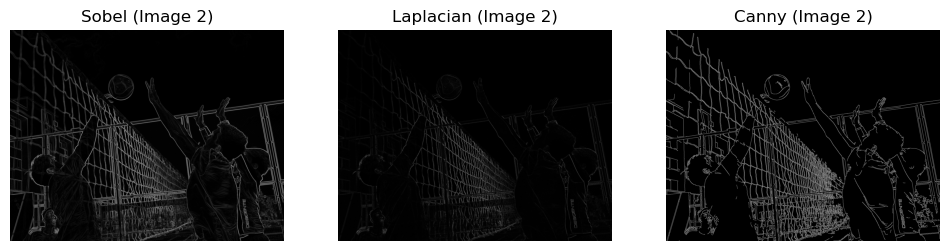

In [21]:
#TASK 3:
url = 'https://static.tildacdn.com/tild3237-3938-4436-a462-616432363738/Cover.png'
urllib.request.urlretrieve(url, 'image2.png')

image2 = cv2.imread('image2.png')
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

sobel_x = cv2.Sobel(image2, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image2, cv2.CV_64F, 0, 1, ksize=3)

sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

sobel_magnitude = cv2.normalize(sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX)
sobel_magnitude = sobel_magnitude.astype(np.uint8)

laplacian2 = cv2.Laplacian(image2, cv2.CV_64F)
laplacian2 = cv2.normalize(np.abs(laplacian2), None, 0, 255, cv2.NORM_MINMAX)
laplacian2 = laplacian2.astype(np.uint8)


canny2 = cv2.Canny(image2, 100, 200)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel (Image 2)')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(laplacian2, cmap='gray')
plt.title('Laplacian (Image 2)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(canny2, cmap='gray')
plt.title('Canny (Image 2)')
plt.axis('off')

plt.show()